## (01) Install & Import Dependencies

In [1]:
import os, re, time, random, warnings
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from collections import defaultdict

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence

import nltk
from nltk.tokenize import word_tokenize
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)

import gensim
from gensim.models import Word2Vec, FastText, KeyedVectors
import gensim.downloader as gensim_api

from transformers import BertTokenizerFast, BertModel, AutoTokenizer
from torchcrf import CRF
from seqeval.metrics import f1_score, classification_report

warnings.filterwarnings('ignore')

# ─── Reproducibility ─────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

if torch.cuda.is_available():
    DEVICE = torch.device('cuda')
elif torch.backends.mps.is_available():
    DEVICE = torch.device('mps')   # ← Apple GPU acceleration
else:
    DEVICE = torch.device('cpu')

print(f'Using device: {DEVICE}')

Using device: mps


## (02) Load BC5CDR Dataset

In [6]:
# ── Set your paths here ──────────────────────────────────────────────────────
TRAIN_FILE = 'train.txt'
VAL_FILE   = 'val.txt'
TEST_FILE  = 'test.txt'

# ─── Parser ───────────────────────────────────────────────────────────────────
def read_conll(filepath):
    """Read CoNLL-style file. Returns list of (tokens, tags) tuples.
    Handles both TAB and SPACE separators, and skips doc-start lines."""
    sentences, tokens, tags = [], [], []
    with open(filepath, encoding='utf-8') as f:
        for line in f:
            line = line.rstrip('\n')
            if line.startswith('-DOCSTART-') or line.startswith('#'):
                continue
            if line.strip() == '':
                if tokens:
                    sentences.append((tokens, tags))
                    tokens, tags = [], []
            else:
                parts = line.split('\t') if '\t' in line else line.split()
                if len(parts) >= 2:
                    tokens.append(parts[0])
                    tags.append(parts[-1])   # last column = NER tag
    if tokens:
        sentences.append((tokens, tags))
    return sentences

train_data = read_conll(TRAIN_FILE)
val_data   = read_conll(VAL_FILE)
test_data  = read_conll(TEST_FILE)

print(f'Train sentences : {len(train_data)}')
print(f'Val   sentences : {len(val_data)}')
print(f'Test  sentences : {len(test_data)}')
print('\nSample sentence:')
print(train_data[0])

Train sentences : 4560
Val   sentences : 4581
Test  sentences : 4797

Sample sentence:
(['Selegiline', '-', 'induced', 'postural', 'hypotension', 'in', 'Parkinson', "'", 's', 'disease', ':', 'a', 'longitudinal', 'study', 'on', 'the', 'effects', 'of', 'drug', 'withdrawal', '.'], ['O', 'O', 'O', 'B-Disease', 'I-Disease', 'O', 'B-Disease', 'I-Disease', 'I-Disease', 'I-Disease', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O'])



## (03) Build Vocabulary & Tag Mappings

In [7]:
PAD_TOKEN = '<PAD>'
UNK_TOKEN = '<UNK>'

# ─── Build vocab from TRAIN only (standard NLP practice) ─────────────────────
all_train_tokens = [tok for sent, _ in train_data for tok in sent]
vocab = sorted(set(all_train_tokens))
word2idx = {PAD_TOKEN: 0, UNK_TOKEN: 1}
for w in vocab:
    word2idx[w] = len(word2idx)
idx2word = {v: k for k, v in word2idx.items()}

# ─── Tag mappings ─────────────────────────────────────────────────────────────
all_tags = sorted(set(tag for _, tags in train_data for tag in tags))
tag2idx  = {PAD_TOKEN: 0}
for t in all_tags:
    tag2idx[t] = len(tag2idx)
idx2tag = {v: k for k, v in tag2idx.items()}

VOCAB_SIZE  = len(word2idx)
NUM_CLASSES = len(tag2idx)
print(f'Vocabulary size : {VOCAB_SIZE}')
print(f'Tag set         : {list(tag2idx.keys())}')

Vocabulary size : 9983
Tag set         : ['<PAD>', 'B-Disease', 'I-Disease', 'O']


## (4) Tokenizers

In [8]:
from transformers import AutoTokenizer as HFTokenizer

# ─── Load HuggingFace tokenizer once ─────────────────────────────────────────
HF_MODEL_NAME = 'bert-base-cased'
hf_tokenizer  = HFTokenizer.from_pretrained(HF_MODEL_NAME)

# ─────────────────────────────────────────────────────────────────────────────
def whitespace_tokenize(text):
    """Simple whitespace split."""
    return text.split()

def nltk_tokenize(text):
    """NLTK word tokenizer."""
    return word_tokenize(text)

def hf_tokenize(text):
    """HuggingFace BPE/WordPiece tokenizer — returns subword tokens."""
    return hf_tokenizer.tokenize(text)

TOKENIZERS = {
    'Whitespace' : whitespace_tokenize,
    'NLTK'       : nltk_tokenize,
    'BPE_WP'     : hf_tokenize,
}

# ─── Demo ─────────────────────────────────────────────────────────────────────
sample = 'patients with diabetes mellitus were treated'
for name, fn in TOKENIZERS.items():
    print(f'{name:12s}: {fn(sample)}')

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/213k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/436k [00:00<?, ?B/s]

Whitespace  : ['patients', 'with', 'diabetes', 'mellitus', 'were', 'treated']
NLTK        : ['patients', 'with', 'diabetes', 'mellitus', 'were', 'treated']
BPE_WP      : ['patients', 'with', 'diabetes', 'me', '##lli', '##tus', 'were', 'treated']


## (5) Dataset & Dataloader 

In [9]:
MAX_LEN = 128

class NERDataset(Dataset):
    """
    Dataset for non-BERT embeddings (Word2Vec, GloVe, FastText).
    Tokenizer is applied per-word to get final sub-word indices or
    word indices, then tags are aligned to first sub-token (BIO kept).
    """
    def __init__(self, data, word2idx, tag2idx, tokenizer_fn, max_len=MAX_LEN):
        self.samples = []
        for tokens, tags in data:
            ids, tag_ids = [], []
            for tok, tag in zip(tokens, tags):
                sub = tokenizer_fn(tok)
                if not sub:
                    sub = [tok]
                for i, s in enumerate(sub):
                    ids.append(word2idx.get(s, word2idx.get(tok, word2idx[UNK_TOKEN])))
                    # Only first sub-token keeps real tag; rest get 'O'
                    tag_ids.append(tag2idx.get(tag if i == 0 else 'O', tag2idx['O']))
            ids    = ids[:max_len]
            tag_ids = tag_ids[:max_len]
            self.samples.append((torch.tensor(ids, dtype=torch.long),
                                  torch.tensor(tag_ids, dtype=torch.long)))

    def __len__(self):  return len(self.samples)
    def __getitem__(self, i): return self.samples[i]


def collate_fn(batch):
    """Pad sequences in a batch to equal length."""
    seqs, tags = zip(*batch)
    seqs_padded = pad_sequence(seqs, batch_first=True, padding_value=0)
    tags_padded = pad_sequence(tags, batch_first=True, padding_value=0)
    mask = (seqs_padded != 0).bool()
    return seqs_padded, tags_padded, mask


def make_loaders(train_data, val_data, test_data, word2idx, tag2idx,
                 tokenizer_fn, batch_size=32):
    tr = NERDataset(train_data, word2idx, tag2idx, tokenizer_fn)
    vl = NERDataset(val_data,   word2idx, tag2idx, tokenizer_fn)
    te = NERDataset(test_data,  word2idx, tag2idx, tokenizer_fn)
    return (
        DataLoader(tr, batch_size=batch_size, shuffle=True,  collate_fn=collate_fn),
        DataLoader(vl, batch_size=batch_size, shuffle=False, collate_fn=collate_fn),
        DataLoader(te, batch_size=batch_size, shuffle=False, collate_fn=collate_fn),
    )

print('Dataset utilities defined.')

Dataset utilities defined.


## (6) Embedding Matrices

In [10]:
EMBED_DIM = 100

def build_embedding_matrix(keyed_vectors, word2idx, embed_dim):
    """Build (vocab_size × embed_dim) matrix from gensim KeyedVectors."""
    matrix = np.zeros((len(word2idx), embed_dim))
    hits = 0
    for word, idx in word2idx.items():
        if word in keyed_vectors:
            matrix[idx] = keyed_vectors[word]
            hits += 1
    print(f'  Coverage: {hits}/{len(word2idx)} ({100*hits/len(word2idx):.1f}%)')
    return torch.tensor(matrix, dtype=torch.float)


# ── 6.1 Word2Vec (trained on BC5CDR corpus) ───────────────────────────────────
print('Training Word2Vec on BC5CDR train corpus...')
corpus_sents = [tokens for tokens, _ in train_data]
w2v_model = Word2Vec(sentences=corpus_sents, vector_size=EMBED_DIM,
                     window=5, min_count=1, workers=4, epochs=10, seed=SEED)
w2v_matrix = build_embedding_matrix(w2v_model.wv, word2idx, EMBED_DIM)
print('  Word2Vec done.')


# ── 6.2 GloVe (glove-wiki-gigaword-100 via gensim) ───────────────────────────
print('Loading GloVe (glove-wiki-gigaword-100)...')
glove_kv = gensim_api.load('glove-wiki-gigaword-100')
glove_matrix = build_embedding_matrix(glove_kv, word2idx, EMBED_DIM)
print('  GloVe done.')


# ── 6.3 FastText (trained on BC5CDR corpus) ───────────────────────────────────
print('Training FastText on BC5CDR train corpus...')
ft_model = FastText(sentences=corpus_sents, vector_size=EMBED_DIM,
                    window=5, min_count=1, workers=4, epochs=10, seed=SEED)
ft_matrix = build_embedding_matrix(ft_model.wv, word2idx, EMBED_DIM)
print('  FastText done.')

EMBEDDING_MATRICES = {
    'Word2Vec': w2v_matrix,
    'GloVe'   : glove_matrix,
    'FastText' : ft_matrix,
}
print('\nAll static embeddings ready.')

Training Word2Vec on BC5CDR train corpus...


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


  Coverage: 9981/9983 (100.0%)
  Word2Vec done.
Loading GloVe (glove-wiki-gigaword-100)...
[==================================================] 100.0% 128.1/128.1MB downloaded
  Coverage: 6690/9983 (67.0%)
  GloVe done.
Training FastText on BC5CDR train corpus...


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


  Coverage: 9983/9983 (100.0%)
  FastText done.

All static embeddings ready.


## (07) Model Architecture — BiLSTM + CRF

In [11]:
class BiLSTM_CRF(nn.Module):
    """
    BiLSTM + CRF NER model for static embeddings (Word2Vec / GloVe / FastText).
    Embedding layer is initialised from a pre-built weight matrix.
    """
    def __init__(self, embed_matrix, hidden_dim, num_tags,
                 dropout=0.3, freeze_embed=False):
        super().__init__()
        vocab_size, embed_dim = embed_matrix.shape

        self.embedding = nn.Embedding.from_pretrained(
            embed_matrix, padding_idx=0, freeze=freeze_embed)
        self.dropout   = nn.Dropout(dropout)
        self.lstm      = nn.LSTM(embed_dim, hidden_dim // 2,
                                  num_layers=2, bidirectional=True,
                                  batch_first=True, dropout=dropout)
        self.fc        = nn.Linear(hidden_dim, num_tags)
        self.crf       = CRF(num_tags, batch_first=True)

    def forward(self, x, tags=None, mask=None):
        emb = self.dropout(self.embedding(x))          # (B, L, E)
        out, _ = self.lstm(emb)                         # (B, L, H)
        emissions = self.fc(self.dropout(out))          # (B, L, T)
        if tags is not None:
            # CRF requires padding_tag=0 to be masked
            loss = -self.crf(emissions, tags, mask=mask, reduction='mean')
            return loss
        return self.crf.decode(emissions, mask=mask)    # list of tag-id seqs

print('BiLSTM_CRF model defined.')

BiLSTM_CRF model defined.


## (08) Training & Evaluation Utilities

In [12]:
def token_accuracy(preds_batch, tags_batch, mask_batch):
    """Per-token accuracy ignoring PAD positions."""
    correct, total = 0, 0
    for preds, tags, mask in zip(preds_batch, tags_batch, mask_batch):
        for p, t, m in zip(preds, tags.tolist(), mask.tolist()):
            if m:
                correct += int(p == t)
                total   += 1
    return correct / total if total > 0 else 0.0


def seqeval_f1(all_preds, all_tags, idx2tag):
    """Compute seqeval F1 from list-of-lists of integer IDs."""
    pred_seqs = [[idx2tag[i] for i in seq] for seq in all_preds]
    true_seqs = [[idx2tag[i] for i in seq] for seq in all_tags]
    return f1_score(true_seqs, pred_seqs)


def train_one_epoch(model, loader, optimizer, device):
    model.train()
    total_loss, acc_sum, n_batches = 0, 0, 0
    for x, y, mask in loader:
        x, y, mask = x.to(device), y.to(device), mask.to(device)
        optimizer.zero_grad()
        loss = model(x, tags=y, mask=mask)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
        optimizer.step()
        total_loss += loss.item()
        preds = model(x, mask=mask)
        acc_sum += token_accuracy(preds, y.cpu(), mask.cpu())
        n_batches += 1
    return total_loss / n_batches, acc_sum / n_batches


@torch.no_grad()
def evaluate(model, loader, device, idx2tag):
    model.eval()
    acc_sum, n_batches = 0, 0
    all_preds, all_tags = [], []
    for x, y, mask in loader:
        x, y, mask = x.to(device), y.to(device), mask.to(device)
        preds = model(x, mask=mask)           # list of lists
        acc_sum += token_accuracy(preds, y.cpu(), mask.cpu())
        n_batches += 1
        for pred_seq, tag_seq, m in zip(preds, y.cpu().tolist(), mask.cpu().tolist()):
            real_len = sum(m)
            all_preds.append(pred_seq[:real_len])
            all_tags.append(tag_seq[:real_len])
    acc = acc_sum / n_batches
    f1  = seqeval_f1(all_preds, all_tags, idx2tag)
    return acc, f1, all_preds, all_tags


def train_model(model, train_loader, val_loader, test_loader,
                n_epochs=15, lr=1e-3, device=DEVICE):
    """
    Full training loop. Returns history dict with:
      train_acc, val_acc, test_acc, train_loss (per epoch)
    and final val_f1, test_f1.
    """
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='max', patience=3, factor=0.5)

    history = {'train_acc': [], 'val_acc': [], 'test_acc': [], 'train_loss': []}
    best_val_f1, best_state = 0.0, None

    for epoch in range(1, n_epochs + 1):
        t_loss, t_acc = train_one_epoch(model, train_loader, optimizer, device)
        v_acc,  v_f1, _, _ = evaluate(model, val_loader,  device, idx2tag)
        te_acc, te_f1, _, _ = evaluate(model, test_loader, device, idx2tag)

        scheduler.step(v_f1)
        history['train_loss'].append(t_loss)
        history['train_acc'].append(t_acc)
        history['val_acc'].append(v_acc)
        history['test_acc'].append(te_acc)

        if v_f1 > best_val_f1:
            best_val_f1 = v_f1
            best_state  = {k: v.clone() for k, v in model.state_dict().items()}

        print(f'  Epoch {epoch:02d} | loss {t_loss:.4f} | '
              f'tr_acc {t_acc:.4f} | val_acc {v_acc:.4f} | '
              f'te_acc {te_acc:.4f} | val_F1 {v_f1:.4f}')

    # Restore best weights and get final test metrics
    model.load_state_dict(best_state)
    _, final_val_f1,  _, _  = evaluate(model, val_loader,  device, idx2tag)
    _, final_test_f1, _, _  = evaluate(model, test_loader, device, idx2tag)
    history['val_f1']  = final_val_f1
    history['test_f1'] = final_test_f1
    return history

print('Training utilities defined.')

Training utilities defined.


## (09) BERT Fine-tuning Model & Dataset

In [13]:
class BERTDataset(Dataset):
    """
    Dataset for BERT. Handles sub-word alignment: only first sub-token
    of each word gets the real BIO tag; others get -100 (ignored by loss).
    Supports three tokenization strategies:
      - 'whitespace': join & re-split words, no NLTK
      - 'nltk'      : join & NLTK-tokenize, then BERT-encode
      - 'bpe_wp'    : direct BERT WordPiece (standard)
    """
    def __init__(self, data, tag2idx, hf_tok, mode='bpe_wp', max_len=128):
        self.samples = []
        self.max_len = max_len
        self.hf_tok  = hf_tok
        for tokens, tags in data:
            if mode == 'whitespace':
                words = ' '.join(tokens).split()
                word_tags = self._align_tags(tokens, tags, words)
            elif mode == 'nltk':
                words = word_tokenize(' '.join(tokens))
                word_tags = self._align_tags(tokens, tags, words)
            else:  # bpe_wp — standard
                words, word_tags = tokens, tags

            enc = hf_tok(words, is_split_into_words=True,
                          max_length=max_len, truncation=True, padding='max_length')
            label_ids = []
            prev_word_id = None
            for word_id in enc.word_ids():
                if word_id is None:
                    label_ids.append(-100)
                elif word_id != prev_word_id:
                    label_ids.append(tag2idx.get(word_tags[word_id] if word_id < len(word_tags) else 'O', 0))
                else:
                    label_ids.append(-100)
                prev_word_id = word_id

            self.samples.append({
                'input_ids'      : torch.tensor(enc['input_ids'],      dtype=torch.long),
                'attention_mask' : torch.tensor(enc['attention_mask'],  dtype=torch.long),
                'token_type_ids' : torch.tensor(enc['token_type_ids'],  dtype=torch.long),
                'labels'         : torch.tensor(label_ids,              dtype=torch.long),
            })

    @staticmethod
    def _align_tags(orig_tokens, orig_tags, new_tokens):
        """Greedy character-level re-alignment of tags to new token list."""
        orig_str = ' '.join(orig_tokens)
        new_tags, i = [], 0
        for nt in new_tokens:
            idx = orig_str.find(nt, i)
            char_pos = idx if idx != -1 else i
            # Map char position back to original token index
            cum = 0
            tag = 'O'
            for k, ot in enumerate(orig_tokens):
                if cum <= char_pos < cum + len(ot):
                    tag = orig_tags[k]
                    break
                cum += len(ot) + 1
            new_tags.append(tag)
            i = char_pos + len(nt)
        return new_tags

    def __len__(self):  return len(self.samples)
    def __getitem__(self, i): return self.samples[i]


class BERT_CRF(nn.Module):
    """BERT encoder + linear projection + CRF decoder."""
    def __init__(self, bert_name, num_tags, dropout=0.2):
        super().__init__()
        self.bert    = BertModel.from_pretrained(bert_name)
        self.dropout = nn.Dropout(dropout)
        self.fc      = nn.Linear(self.bert.config.hidden_size, num_tags)
        self.crf     = CRF(num_tags, batch_first=True)

    def forward(self, input_ids, attention_mask, token_type_ids, labels=None):
        out = self.bert(input_ids=input_ids,
                        attention_mask=attention_mask,
                        token_type_ids=token_type_ids)
        emissions = self.fc(self.dropout(out.last_hidden_state))  # (B,L,T)
        mask = attention_mask.bool()
        if labels is not None:
            # Replace -100 with 0 for CRF (mask hides them anyway via attention)
            safe_labels = labels.clone()
            safe_labels[safe_labels == -100] = 0
            loss = -self.crf(emissions, safe_labels, mask=mask, reduction='mean')
            return loss
        return self.crf.decode(emissions, mask=mask)


def bert_token_accuracy(preds_batch, labels_batch):
    correct, total = 0, 0
    for preds, labels in zip(preds_batch, labels_batch.tolist()):
        for p, l in zip(preds, labels):
            if l != -100:
                correct += int(p == l)
                total   += 1
    return correct / total if total > 0 else 0.0


def train_bert_epoch(model, loader, optimizer, device):
    model.train()
    total_loss, acc_sum, n = 0, 0, 0
    for batch in loader:
        ids  = batch['input_ids'].to(device)
        mask = batch['attention_mask'].to(device)
        ttype = batch['token_type_ids'].to(device)
        labels = batch['labels'].to(device)
        optimizer.zero_grad()
        loss = model(ids, mask, ttype, labels=labels)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        total_loss += loss.item()
        preds = model(ids, mask, ttype)
        acc_sum += bert_token_accuracy(preds, labels.cpu())
        n += 1
    return total_loss / n, acc_sum / n


@torch.no_grad()
def eval_bert(model, loader, device, idx2tag):
    model.eval()
    acc_sum, n = 0, 0
    all_preds, all_trues = [], []
    for batch in loader:
        ids   = batch['input_ids'].to(device)
        mask  = batch['attention_mask'].to(device)
        ttype = batch['token_type_ids'].to(device)
        labels = batch['labels'].to(device)
        preds  = model(ids, mask, ttype)
        acc_sum += bert_token_accuracy(preds, labels.cpu())
        n += 1
        for pred_seq, label_seq in zip(preds, labels.cpu().tolist()):
            p_tags, t_tags = [], []
            for p, l in zip(pred_seq, label_seq):
                if l != -100:
                    p_tags.append(idx2tag.get(p, 'O'))
                    t_tags.append(idx2tag.get(l, 'O'))
            all_preds.append(p_tags)
            all_trues.append(t_tags)
    f1 = f1_score(all_trues, all_preds)
    return acc_sum / n, f1


def train_bert_model(model, train_loader, val_loader, test_loader,
                     n_epochs=6, lr=2e-5, device=DEVICE):
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-2)
    scheduler = optim.lr_scheduler.LinearLR(
        optimizer, start_factor=1.0, end_factor=0.1,
        total_iters=n_epochs)

    history = {'train_acc': [], 'val_acc': [], 'test_acc': [], 'train_loss': []}
    best_val_f1, best_state = 0.0, None

    for epoch in range(1, n_epochs + 1):
        t_loss, t_acc = train_bert_epoch(model, train_loader, optimizer, device)
        v_acc,  v_f1  = eval_bert(model, val_loader,  device, idx2tag)
        te_acc, te_f1 = eval_bert(model, test_loader, device, idx2tag)
        scheduler.step()

        history['train_loss'].append(t_loss)
        history['train_acc'].append(t_acc)
        history['val_acc'].append(v_acc)
        history['test_acc'].append(te_acc)

        if v_f1 > best_val_f1:
            best_val_f1 = v_f1
            best_state  = {k: v.clone() for k, v in model.state_dict().items()}

        print(f'  Epoch {epoch:02d} | loss {t_loss:.4f} | '
              f'tr_acc {t_acc:.4f} | val_acc {v_acc:.4f} | '
              f'te_acc {te_acc:.4f} | val_F1 {v_f1:.4f}')

    model.load_state_dict(best_state)
    _, final_val_f1  = eval_bert(model, val_loader,  device, idx2tag)
    _, final_test_f1 = eval_bert(model, test_loader, device, idx2tag)
    history['val_f1']  = final_val_f1
    history['test_f1'] = final_test_f1
    return history

print('BERT model & training utilities defined.')

BERT model & training utilities defined.


## (10) Plotting Utilities

In [14]:
def plot_accuracy_curves(history, title=''):
    """
    Plot train / val / test accuracy on the SAME axes so overfitting is visible.
    If train >> val/test → overfitting; if all three track → healthy.
    """
    epochs = range(1, len(history['train_acc']) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    # ── Accuracy ────────────────────────────────────────────────────────────
    ax = axes[0]
    ax.plot(epochs, history['train_acc'], 'o-', color='steelblue',  label='Train')
    ax.plot(epochs, history['val_acc'],   's--', color='darkorange', label='Val')
    ax.plot(epochs, history['test_acc'],  '^:', color='forestgreen', label='Test')
    ax.set_xlabel('Epoch'); ax.set_ylabel('Token Accuracy')
    ax.set_title(f'{title}\nAccuracy (overfitting check)')
    ax.legend(); ax.grid(alpha=0.3)
    ax.yaxis.set_major_formatter(ticker.PercentFormatter(xmax=1.0))

    # ── Loss ────────────────────────────────────────────────────────────────
    ax = axes[1]
    ax.plot(epochs, history['train_loss'], 'o-', color='crimson', label='Train Loss')
    ax.set_xlabel('Epoch'); ax.set_ylabel('CRF Loss')
    ax.set_title(f'{title}\nTraining Loss')
    ax.legend(); ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()
    print(f'  Best Val F1  : {history["val_f1"]:.4f}')
    print(f'  Best Test F1 : {history["test_f1"]:.4f}')

print('Plotting utility defined.')

Plotting utility defined.


## (11) Run all Experiments


 Experiment: Word2Vec + Whitespace
  Epoch 01 | loss 5.8604 | tr_acc 0.9431 | val_acc 0.9528 | te_acc 0.9539 | val_F1 0.3585
  Epoch 02 | loss 2.3329 | tr_acc 0.9700 | val_acc 0.9675 | te_acc 0.9673 | val_F1 0.6355
  Epoch 03 | loss 1.3076 | tr_acc 0.9826 | val_acc 0.9645 | te_acc 0.9645 | val_F1 0.6371
  Epoch 04 | loss 0.9387 | tr_acc 0.9873 | val_acc 0.9698 | te_acc 0.9704 | val_F1 0.6848
  Epoch 05 | loss 0.7551 | tr_acc 0.9892 | val_acc 0.9729 | te_acc 0.9728 | val_F1 0.6996
  Epoch 06 | loss 0.6068 | tr_acc 0.9916 | val_acc 0.9664 | te_acc 0.9666 | val_F1 0.6864
  Epoch 07 | loss 0.4793 | tr_acc 0.9928 | val_acc 0.9623 | te_acc 0.9606 | val_F1 0.6772
  Epoch 08 | loss 0.3707 | tr_acc 0.9941 | val_acc 0.9624 | te_acc 0.9608 | val_F1 0.6638
  Epoch 09 | loss 0.3330 | tr_acc 0.9952 | val_acc 0.9703 | te_acc 0.9700 | val_F1 0.7018
  Epoch 10 | loss 0.2631 | tr_acc 0.9965 | val_acc 0.9643 | te_acc 0.9639 | val_F1 0.6857
  Epoch 11 | loss 0.2407 | tr_acc 0.9967 | val_acc 0.9672 | te_a

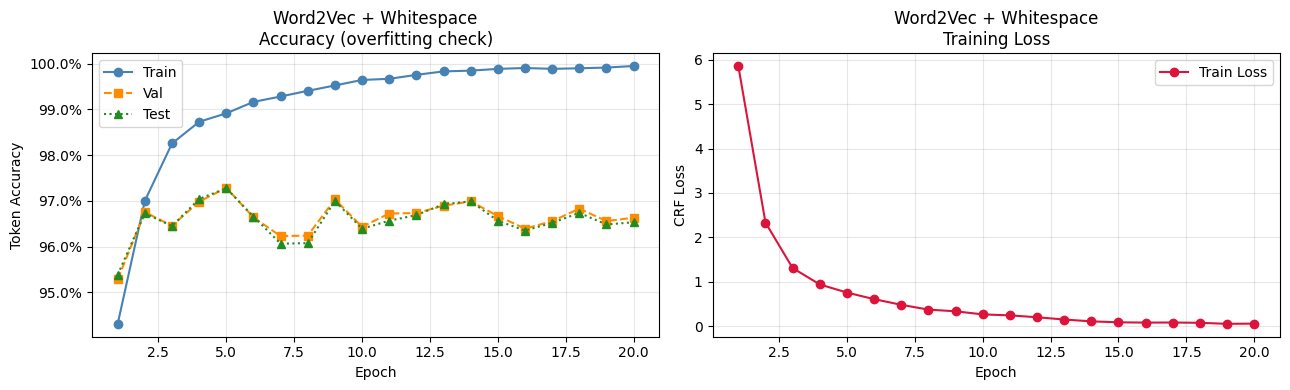

  Best Val F1  : 0.7083
  Best Test F1 : 0.6969

 Experiment: Word2Vec + NLTK
  Epoch 01 | loss 5.9053 | tr_acc 0.9428 | val_acc 0.9544 | te_acc 0.9551 | val_F1 0.4170
  Epoch 02 | loss 2.3354 | tr_acc 0.9707 | val_acc 0.9664 | te_acc 0.9665 | val_F1 0.6292
  Epoch 03 | loss 1.3073 | tr_acc 0.9832 | val_acc 0.9709 | te_acc 0.9699 | val_F1 0.6727
  Epoch 04 | loss 0.9797 | tr_acc 0.9864 | val_acc 0.9631 | te_acc 0.9615 | val_F1 0.6570
  Epoch 05 | loss 0.7666 | tr_acc 0.9895 | val_acc 0.9734 | te_acc 0.9729 | val_F1 0.7103
  Epoch 06 | loss 0.6076 | tr_acc 0.9913 | val_acc 0.9666 | te_acc 0.9651 | val_F1 0.6873
  Epoch 07 | loss 0.5313 | tr_acc 0.9924 | val_acc 0.9725 | te_acc 0.9722 | val_F1 0.7143
  Epoch 08 | loss 0.3720 | tr_acc 0.9946 | val_acc 0.9671 | te_acc 0.9665 | val_F1 0.6960
  Epoch 09 | loss 0.3150 | tr_acc 0.9953 | val_acc 0.9589 | te_acc 0.9547 | val_F1 0.6751
  Epoch 10 | loss 0.2696 | tr_acc 0.9964 | val_acc 0.9614 | te_acc 0.9603 | val_F1 0.6757
  Epoch 11 | loss 0.24

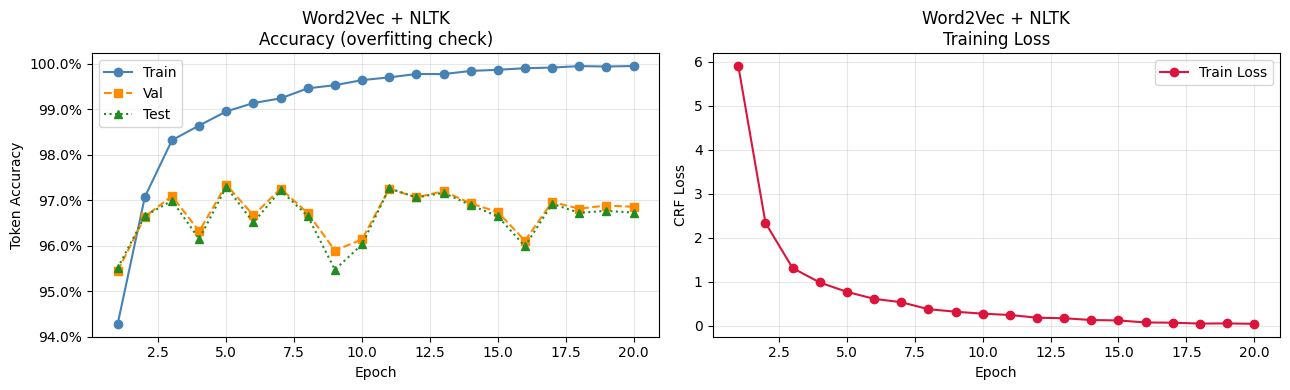

  Best Val F1  : 0.7144
  Best Test F1 : 0.6992

 Experiment: Word2Vec + BPE_WP
  Epoch 01 | loss 7.4838 | tr_acc 0.9569 | val_acc 0.9605 | te_acc 0.9610 | val_F1 0.1877
  Epoch 02 | loss 3.4648 | tr_acc 0.9688 | val_acc 0.9706 | te_acc 0.9695 | val_F1 0.5901
  Epoch 03 | loss 2.0444 | tr_acc 0.9818 | val_acc 0.9698 | te_acc 0.9690 | val_F1 0.6456
  Epoch 04 | loss 1.3474 | tr_acc 0.9877 | val_acc 0.9764 | te_acc 0.9762 | val_F1 0.6990
  Epoch 05 | loss 1.0292 | tr_acc 0.9907 | val_acc 0.9764 | te_acc 0.9758 | val_F1 0.7135
  Epoch 06 | loss 0.7933 | tr_acc 0.9924 | val_acc 0.9756 | te_acc 0.9756 | val_F1 0.7179
  Epoch 07 | loss 0.6187 | tr_acc 0.9940 | val_acc 0.9747 | te_acc 0.9747 | val_F1 0.7119
  Epoch 08 | loss 0.4930 | tr_acc 0.9956 | val_acc 0.9725 | te_acc 0.9725 | val_F1 0.7029
  Epoch 09 | loss 0.3920 | tr_acc 0.9966 | val_acc 0.9724 | te_acc 0.9724 | val_F1 0.6994
  Epoch 10 | loss 0.2907 | tr_acc 0.9971 | val_acc 0.9699 | te_acc 0.9703 | val_F1 0.6785
  Epoch 11 | loss 0.

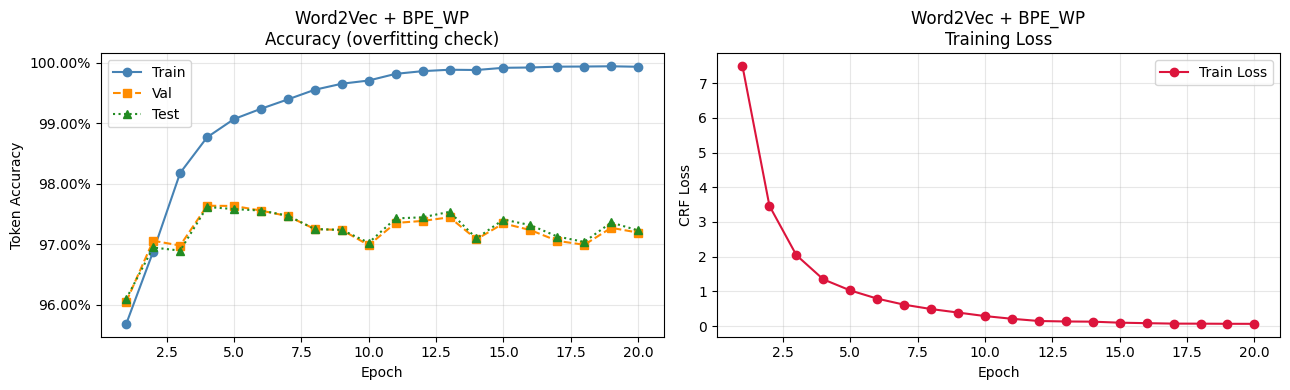

  Best Val F1  : 0.7179
  Best Test F1 : 0.7051

 Experiment: GloVe + Whitespace
  Epoch 01 | loss 4.8490 | tr_acc 0.9514 | val_acc 0.9642 | te_acc 0.9643 | val_F1 0.5478
  Epoch 02 | loss 2.2856 | tr_acc 0.9696 | val_acc 0.9706 | te_acc 0.9701 | val_F1 0.6619
  Epoch 03 | loss 1.5879 | tr_acc 0.9773 | val_acc 0.9702 | te_acc 0.9713 | val_F1 0.6917
  Epoch 04 | loss 1.1845 | tr_acc 0.9829 | val_acc 0.9735 | te_acc 0.9737 | val_F1 0.7254
  Epoch 05 | loss 0.9308 | tr_acc 0.9860 | val_acc 0.9720 | te_acc 0.9723 | val_F1 0.7218
  Epoch 06 | loss 0.7439 | tr_acc 0.9885 | val_acc 0.9756 | te_acc 0.9753 | val_F1 0.7420
  Epoch 07 | loss 0.6058 | tr_acc 0.9901 | val_acc 0.9762 | te_acc 0.9759 | val_F1 0.7521
  Epoch 08 | loss 0.4922 | tr_acc 0.9918 | val_acc 0.9696 | te_acc 0.9697 | val_F1 0.7212
  Epoch 09 | loss 0.4237 | tr_acc 0.9930 | val_acc 0.9732 | te_acc 0.9721 | val_F1 0.7386
  Epoch 10 | loss 0.3265 | tr_acc 0.9949 | val_acc 0.9732 | te_acc 0.9737 | val_F1 0.7432
  Epoch 11 | loss 0

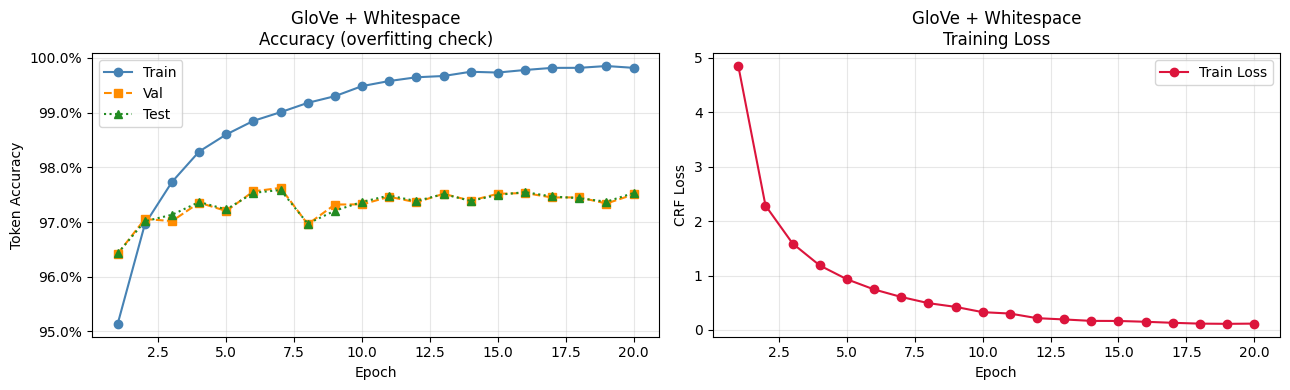

  Best Val F1  : 0.7521
  Best Test F1 : 0.7317

 Experiment: GloVe + NLTK
  Epoch 01 | loss 4.9159 | tr_acc 0.9503 | val_acc 0.9639 | te_acc 0.9636 | val_F1 0.5571
  Epoch 02 | loss 2.2982 | tr_acc 0.9688 | val_acc 0.9705 | te_acc 0.9700 | val_F1 0.6679
  Epoch 03 | loss 1.5772 | tr_acc 0.9770 | val_acc 0.9730 | te_acc 0.9737 | val_F1 0.7094
  Epoch 04 | loss 1.2267 | tr_acc 0.9822 | val_acc 0.9703 | te_acc 0.9714 | val_F1 0.7041
  Epoch 05 | loss 0.9197 | tr_acc 0.9859 | val_acc 0.9732 | te_acc 0.9737 | val_F1 0.7286
  Epoch 06 | loss 0.7496 | tr_acc 0.9882 | val_acc 0.9732 | te_acc 0.9738 | val_F1 0.7413
  Epoch 07 | loss 0.5994 | tr_acc 0.9906 | val_acc 0.9744 | te_acc 0.9746 | val_F1 0.7384
  Epoch 08 | loss 0.5145 | tr_acc 0.9922 | val_acc 0.9747 | te_acc 0.9748 | val_F1 0.7520
  Epoch 09 | loss 0.4196 | tr_acc 0.9936 | val_acc 0.9729 | te_acc 0.9740 | val_F1 0.7376
  Epoch 10 | loss 0.3471 | tr_acc 0.9947 | val_acc 0.9744 | te_acc 0.9748 | val_F1 0.7486
  Epoch 11 | loss 0.2882 

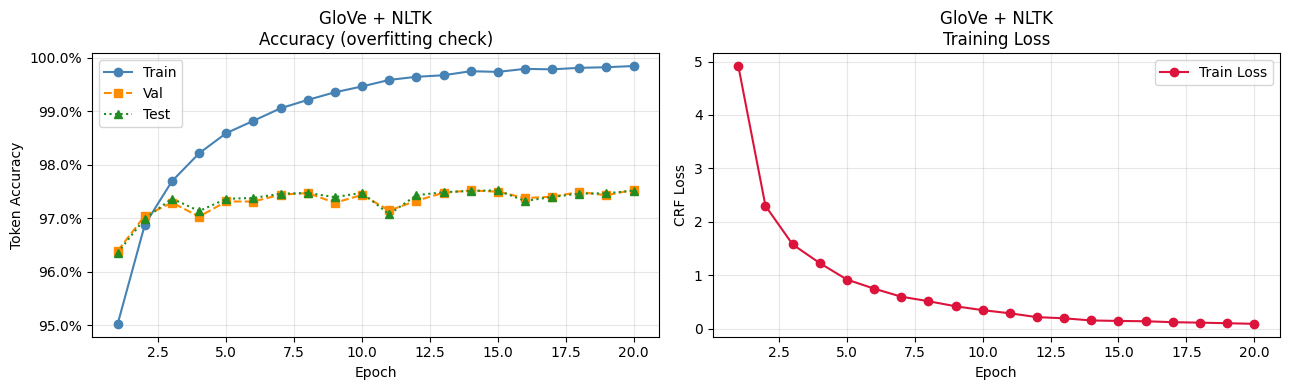

  Best Val F1  : 0.7534
  Best Test F1 : 0.7349

 Experiment: GloVe + BPE_WP
  Epoch 01 | loss 6.3945 | tr_acc 0.9591 | val_acc 0.9680 | te_acc 0.9688 | val_F1 0.4524
  Epoch 02 | loss 2.9349 | tr_acc 0.9737 | val_acc 0.9756 | te_acc 0.9754 | val_F1 0.6703
  Epoch 03 | loss 1.9986 | tr_acc 0.9815 | val_acc 0.9777 | te_acc 0.9774 | val_F1 0.7249
  Epoch 04 | loss 1.5492 | tr_acc 0.9856 | val_acc 0.9794 | te_acc 0.9794 | val_F1 0.7430
  Epoch 05 | loss 1.1974 | tr_acc 0.9887 | val_acc 0.9805 | te_acc 0.9803 | val_F1 0.7627
  Epoch 06 | loss 0.9445 | tr_acc 0.9907 | val_acc 0.9808 | te_acc 0.9808 | val_F1 0.7683
  Epoch 07 | loss 0.7842 | tr_acc 0.9922 | val_acc 0.9793 | te_acc 0.9800 | val_F1 0.7663
  Epoch 08 | loss 0.6191 | tr_acc 0.9938 | val_acc 0.9804 | te_acc 0.9808 | val_F1 0.7773
  Epoch 09 | loss 0.5225 | tr_acc 0.9951 | val_acc 0.9786 | te_acc 0.9792 | val_F1 0.7620
  Epoch 10 | loss 0.4436 | tr_acc 0.9956 | val_acc 0.9791 | te_acc 0.9793 | val_F1 0.7706
  Epoch 11 | loss 0.346

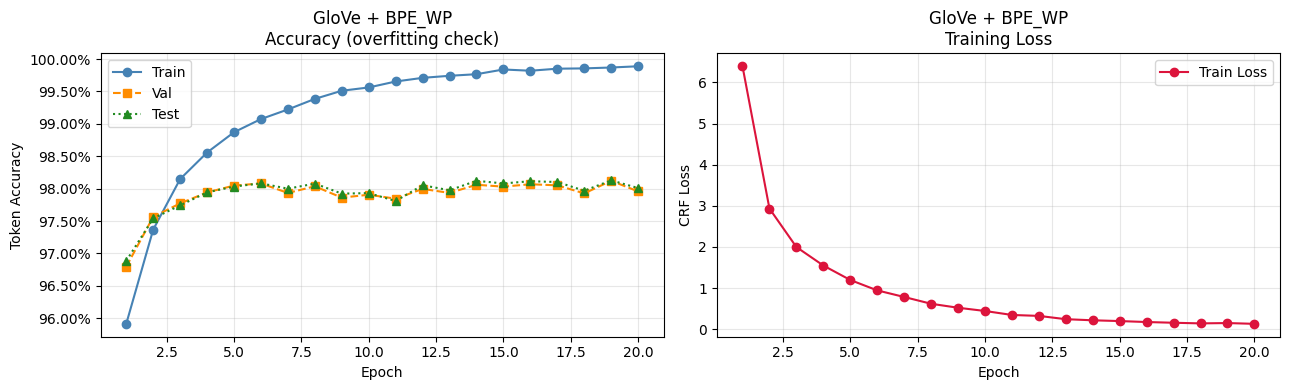

  Best Val F1  : 0.7830
  Best Test F1 : 0.7708

 Experiment: FastText + Whitespace
  Epoch 01 | loss 6.1313 | tr_acc 0.9412 | val_acc 0.9496 | te_acc 0.9505 | val_F1 0.3025
  Epoch 02 | loss 2.6087 | tr_acc 0.9657 | val_acc 0.9667 | te_acc 0.9656 | val_F1 0.6140
  Epoch 03 | loss 1.7019 | tr_acc 0.9773 | val_acc 0.9655 | te_acc 0.9647 | val_F1 0.6352
  Epoch 04 | loss 1.2285 | tr_acc 0.9825 | val_acc 0.9579 | te_acc 0.9572 | val_F1 0.5982
  Epoch 05 | loss 1.0568 | tr_acc 0.9856 | val_acc 0.9710 | te_acc 0.9700 | val_F1 0.6894
  Epoch 06 | loss 0.8974 | tr_acc 0.9868 | val_acc 0.9686 | te_acc 0.9678 | val_F1 0.6734
  Epoch 07 | loss 0.7427 | tr_acc 0.9886 | val_acc 0.9590 | te_acc 0.9557 | val_F1 0.6564
  Epoch 08 | loss 0.6336 | tr_acc 0.9899 | val_acc 0.9587 | te_acc 0.9563 | val_F1 0.6420
  Epoch 09 | loss 0.5447 | tr_acc 0.9909 | val_acc 0.9540 | te_acc 0.9530 | val_F1 0.6201
  Epoch 10 | loss 0.4081 | tr_acc 0.9929 | val_acc 0.9717 | te_acc 0.9702 | val_F1 0.7110
  Epoch 11 | los

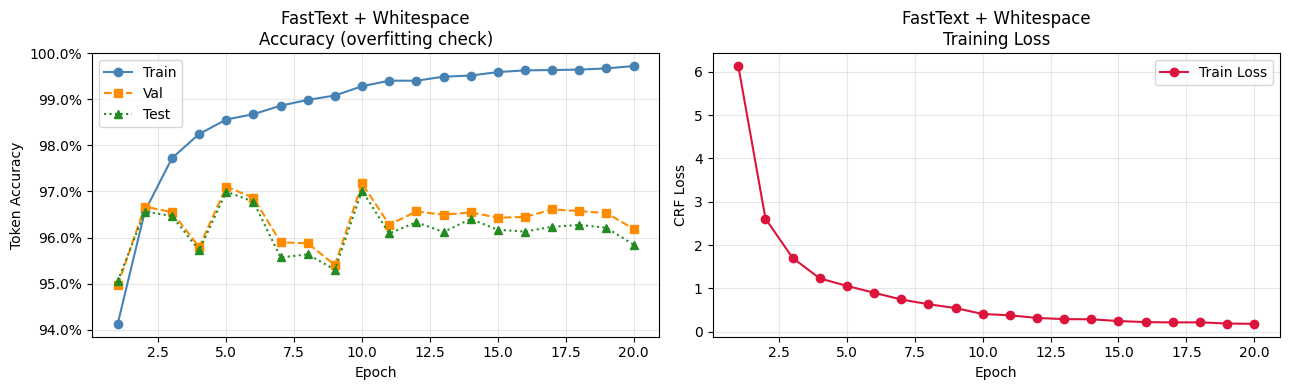

  Best Val F1  : 0.7110
  Best Test F1 : 0.6904

 Experiment: FastText + NLTK
  Epoch 01 | loss 5.8911 | tr_acc 0.9415 | val_acc 0.9490 | te_acc 0.9506 | val_F1 0.2447
  Epoch 02 | loss 2.6087 | tr_acc 0.9660 | val_acc 0.9664 | te_acc 0.9658 | val_F1 0.6182
  Epoch 03 | loss 1.6671 | tr_acc 0.9772 | val_acc 0.9637 | te_acc 0.9628 | val_F1 0.6238
  Epoch 04 | loss 1.2188 | tr_acc 0.9821 | val_acc 0.9655 | te_acc 0.9638 | val_F1 0.6438
  Epoch 05 | loss 1.0062 | tr_acc 0.9854 | val_acc 0.9613 | te_acc 0.9607 | val_F1 0.6268
  Epoch 06 | loss 0.8103 | tr_acc 0.9873 | val_acc 0.9604 | te_acc 0.9588 | val_F1 0.6432
  Epoch 07 | loss 0.7294 | tr_acc 0.9891 | val_acc 0.9670 | te_acc 0.9668 | val_F1 0.6887
  Epoch 08 | loss 0.5889 | tr_acc 0.9903 | val_acc 0.9695 | te_acc 0.9684 | val_F1 0.7015
  Epoch 09 | loss 0.5121 | tr_acc 0.9912 | val_acc 0.9540 | te_acc 0.9533 | val_F1 0.6229
  Epoch 10 | loss 0.4286 | tr_acc 0.9928 | val_acc 0.9609 | te_acc 0.9600 | val_F1 0.6652
  Epoch 11 | loss 0.39

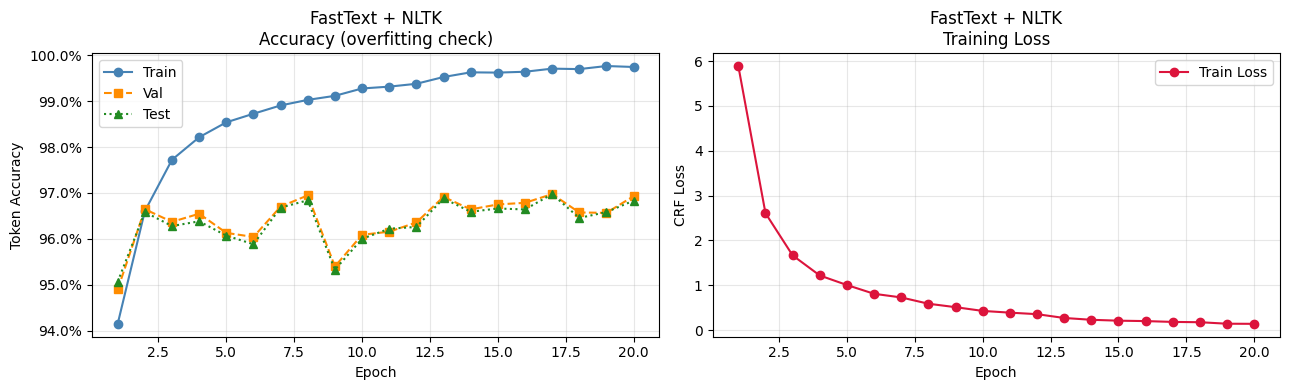

  Best Val F1  : 0.7047
  Best Test F1 : 0.6873

 Experiment: FastText + BPE_WP
  Epoch 01 | loss 7.4860 | tr_acc 0.9569 | val_acc 0.9593 | te_acc 0.9604 | val_F1 0.1526
  Epoch 02 | loss 3.8424 | tr_acc 0.9664 | val_acc 0.9645 | te_acc 0.9629 | val_F1 0.5242
  Epoch 03 | loss 2.5260 | tr_acc 0.9770 | val_acc 0.9721 | te_acc 0.9706 | val_F1 0.6102
  Epoch 04 | loss 1.8912 | tr_acc 0.9823 | val_acc 0.9732 | te_acc 0.9720 | val_F1 0.6674
  Epoch 05 | loss 1.4860 | tr_acc 0.9861 | val_acc 0.9697 | te_acc 0.9681 | val_F1 0.6590
  Epoch 06 | loss 1.2566 | tr_acc 0.9880 | val_acc 0.9713 | te_acc 0.9693 | val_F1 0.6729
  Epoch 07 | loss 1.0334 | tr_acc 0.9893 | val_acc 0.9686 | te_acc 0.9667 | val_F1 0.6655
  Epoch 08 | loss 0.8484 | tr_acc 0.9915 | val_acc 0.9708 | te_acc 0.9694 | val_F1 0.6858
  Epoch 09 | loss 0.7372 | tr_acc 0.9925 | val_acc 0.9759 | te_acc 0.9748 | val_F1 0.7186
  Epoch 10 | loss 0.6115 | tr_acc 0.9938 | val_acc 0.9745 | te_acc 0.9740 | val_F1 0.7130
  Epoch 11 | loss 0.

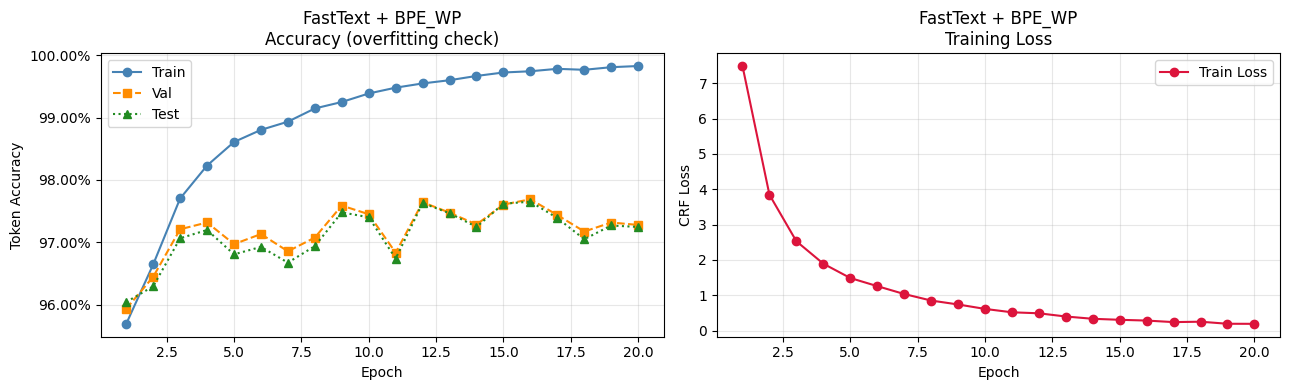

  Best Val F1  : 0.7296
  Best Test F1 : 0.7160


In [ ]:
#─── Hyper-parameters ─────────────────────────────────────────────────────────
HIDDEN_DIM  = 256
EPOCHS      = 20      # increase for better results (30–40 recommended)
LR          = 1e-3
BATCH_SIZE  = 32

results_table = []    # will hold dicts for the summary report

TOKENIZER_MODES = {
    'Whitespace' : whitespace_tokenize,
    'NLTK'       : nltk_tokenize,
    'BPE_WP'     : hf_tokenize,
}

# ─── Loop over Word2Vec / GloVe / FastText × 3 tokenizers ─────────────────────
for embed_name, embed_matrix in EMBEDDING_MATRICES.items():
    for tok_name, tok_fn in TOKENIZER_MODES.items():
        label = f'{embed_name} + {tok_name}'
        separator = '='*60
        print(f'\n{separator}')
        print(f' Experiment: {label}')
        print(f'{separator}')

        train_loader, val_loader, test_loader = make_loaders(
            train_data, val_data, test_data,
            word2idx, tag2idx, tok_fn, BATCH_SIZE)

        model = BiLSTM_CRF(
            embed_matrix=embed_matrix,
            hidden_dim=HIDDEN_DIM,
            num_tags=NUM_CLASSES,
            dropout=0.3,
            freeze_embed=False
        ).to(DEVICE)

        history = train_model(model, train_loader, val_loader, test_loader,
                              n_epochs=EPOCHS, lr=LR, device=DEVICE)
        plot_accuracy_curves(history, title=label)

        results_table.append({
            'Embedding' : embed_name,
            'Tokenizer' : tok_name,
            'Val F1'    : round(history['val_f1'],  4),
            'Test F1'   : round(history['test_f1'], 4),
            'Val Acc'   : round(max(history['val_acc']),  4),
            'Test Acc'  : round(max(history['test_acc']), 4),
        })
        del model
        # Clear device-specific caches safely
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
        elif torch.backends.mps.is_available():
            # torch.mps.empty_cache may not exist on all PyTorch versions; guard it.
            try:
                torch.mps.empty_cache()
            except Exception:
                pass

## (12) BERT Experiments (3 tokenization modes)


 Experiment: BERT + BPE_WP


model.safetensors:   0%|          | 0.00/436M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  Epoch 01 | loss 4.5480 | tr_acc 0.9581 | val_acc 0.9777 | te_acc 0.9776 | val_F1 0.7441
  Epoch 02 | loss 1.1449 | tr_acc 0.9866 | val_acc 0.9788 | te_acc 0.9787 | val_F1 0.7761
  Epoch 03 | loss 0.6563 | tr_acc 0.9931 | val_acc 0.9778 | te_acc 0.9772 | val_F1 0.7811
  Epoch 04 | loss 0.3572 | tr_acc 0.9964 | val_acc 0.9796 | te_acc 0.9796 | val_F1 0.7959
  Epoch 05 | loss 0.2396 | tr_acc 0.9980 | val_acc 0.9775 | te_acc 0.9764 | val_F1 0.7800
  Epoch 06 | loss 0.1599 | tr_acc 0.9986 | val_acc 0.9804 | te_acc 0.9799 | val_F1 0.8032
  Epoch 07 | loss 0.1044 | tr_acc 0.9993 | val_acc 0.9803 | te_acc 0.9794 | val_F1 0.8072
  Epoch 08 | loss 0.0583 | tr_acc 0.9994 | val_acc 0.9793 | te_acc 0.9782 | val_F1 0.8010


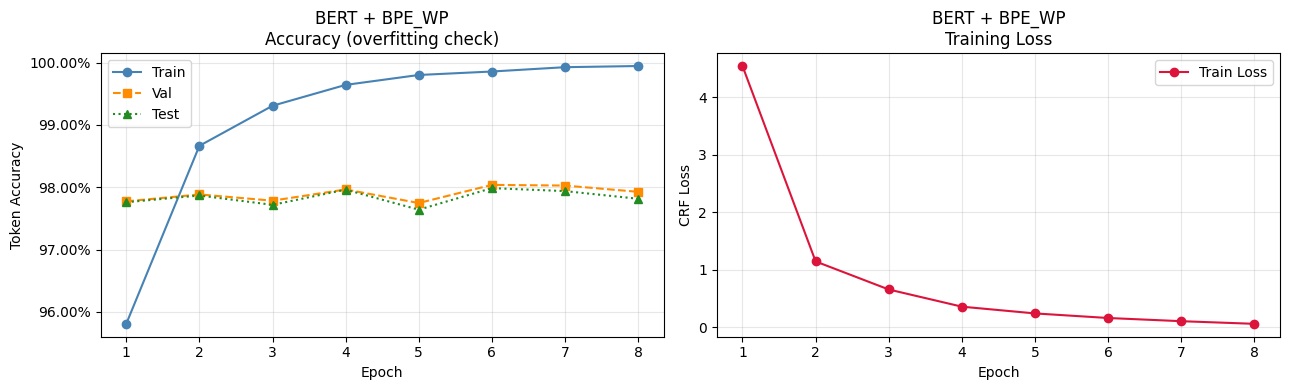

  Best Val F1  : 0.8072
  Best Test F1 : 0.7865

 Experiment: BERT + Whitespace


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  Epoch 01 | loss 4.3707 | tr_acc 0.9634 | val_acc 0.9725 | te_acc 0.9729 | val_F1 0.7071
  Epoch 02 | loss 1.1023 | tr_acc 0.9869 | val_acc 0.9723 | te_acc 0.9709 | val_F1 0.7476
  Epoch 03 | loss 0.6090 | tr_acc 0.9935 | val_acc 0.9800 | te_acc 0.9789 | val_F1 0.7962
  Epoch 04 | loss 0.3450 | tr_acc 0.9966 | val_acc 0.9727 | te_acc 0.9725 | val_F1 0.7611
  Epoch 05 | loss 0.2150 | tr_acc 0.9979 | val_acc 0.9789 | te_acc 0.9788 | val_F1 0.7912
  Epoch 06 | loss 0.1667 | tr_acc 0.9987 | val_acc 0.9769 | te_acc 0.9766 | val_F1 0.7887
  Epoch 07 | loss 0.1230 | tr_acc 0.9991 | val_acc 0.9783 | te_acc 0.9780 | val_F1 0.7969
  Epoch 08 | loss 0.0714 | tr_acc 0.9994 | val_acc 0.9787 | te_acc 0.9789 | val_F1 0.7944


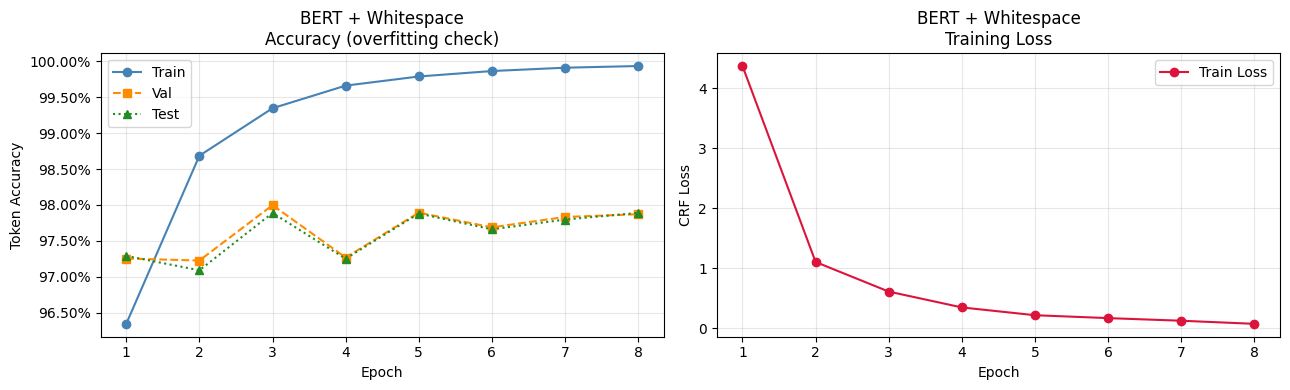

  Best Val F1  : 0.7969
  Best Test F1 : 0.7805

 Experiment: BERT + NLTK


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  Epoch 01 | loss 4.3588 | tr_acc 0.9643 | val_acc 0.9768 | te_acc 0.9770 | val_F1 0.7283
  Epoch 02 | loss 1.1544 | tr_acc 0.9874 | val_acc 0.9799 | te_acc 0.9801 | val_F1 0.7780
  Epoch 03 | loss 0.6424 | tr_acc 0.9930 | val_acc 0.9804 | te_acc 0.9801 | val_F1 0.8006
  Epoch 04 | loss 0.3575 | tr_acc 0.9965 | val_acc 0.9778 | te_acc 0.9768 | val_F1 0.7842
  Epoch 05 | loss 0.2385 | tr_acc 0.9979 | val_acc 0.9806 | te_acc 0.9800 | val_F1 0.7981
  Epoch 06 | loss 0.1604 | tr_acc 0.9986 | val_acc 0.9799 | te_acc 0.9792 | val_F1 0.8050
  Epoch 07 | loss 0.0815 | tr_acc 0.9992 | val_acc 0.9804 | te_acc 0.9804 | val_F1 0.8030
  Epoch 08 | loss 0.0666 | tr_acc 0.9995 | val_acc 0.9800 | te_acc 0.9790 | val_F1 0.8036


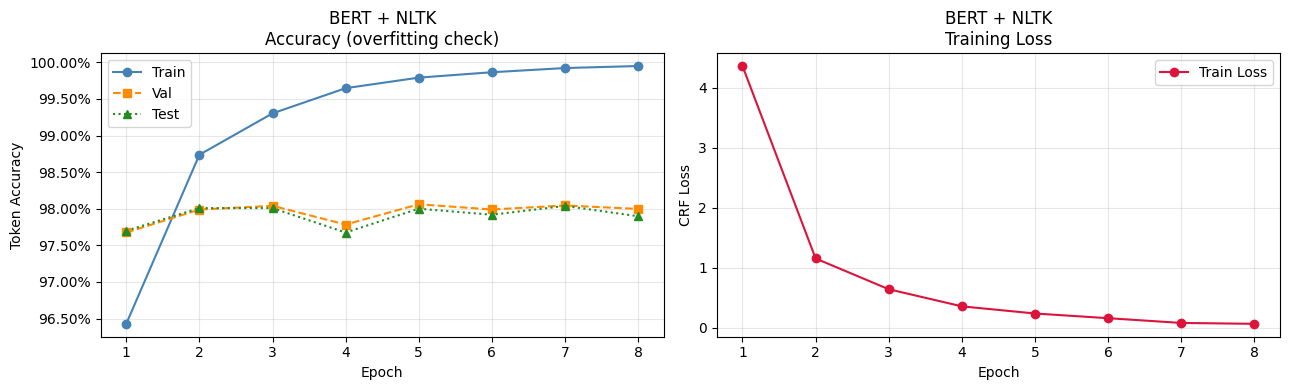

  Best Val F1  : 0.8050
  Best Test F1 : 0.7860


In [20]:
BERT_EPOCHS     = 8       # BERT converges faster; 5–10 is usually enough
BERT_LR         = 2e-5
BERT_BATCH_SIZE = 16      # use 8 if OOM
BERT_NAME       = 'bert-base-cased'

BERT_TOK_MODES = ['bpe_wp', 'whitespace', 'nltk']
BERT_TOK_LABELS = {'bpe_wp': 'BPE_WP', 'whitespace': 'Whitespace', 'nltk': 'NLTK'}

for mode in BERT_TOK_MODES:
    label = f'BERT + {BERT_TOK_LABELS[mode]}'
    separator = '='*60
    print(f'\n{separator}')
    print(f' Experiment: {label}')
    print(f'{separator}')

    tr_ds = BERTDataset(train_data, tag2idx, hf_tokenizer, mode=mode)
    vl_ds = BERTDataset(val_data,   tag2idx, hf_tokenizer, mode=mode)
    te_ds = BERTDataset(test_data,  tag2idx, hf_tokenizer, mode=mode)

    tr_loader = DataLoader(tr_ds, batch_size=BERT_BATCH_SIZE, shuffle=True)
    vl_loader = DataLoader(vl_ds, batch_size=BERT_BATCH_SIZE, shuffle=False)
    te_loader = DataLoader(te_ds, batch_size=BERT_BATCH_SIZE, shuffle=False)

    model = BERT_CRF(BERT_NAME, num_tags=NUM_CLASSES, dropout=0.2).to(DEVICE)

    history = train_bert_model(model, tr_loader, vl_loader, te_loader,
                                n_epochs=BERT_EPOCHS, lr=BERT_LR, device=DEVICE)
    plot_accuracy_curves(history, title=label)

    results_table.append({
        'Embedding' : 'BERT',
        'Tokenizer' : BERT_TOK_LABELS[mode],
        'Val F1'    : round(history['val_f1'],  4),
        'Test F1'   : round(history['test_f1'], 4),
        'Val Acc'   : round(max(history['val_acc']),  4),
        'Test Acc'  : round(max(history['test_acc']), 4),
    })
    del model
    if torch.cuda.is_available():
            torch.cuda.empty_cache()
    elif torch.backends.mps.is_available():
            # torch.mps.empty_cache may not exist on all PyTorch versions; guard it.
        try:
            torch.mps.empty_cache()
        except Exception:
            pass

## (12b) ELMo Experiments (3 tokenization modes)

In [21]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

# Must be before ANY other TF import
import tensorflow as tf
tf.compat.v1.enable_eager_execution()

import tensorflow_hub as hub

print(f'TF version: {tf.__version__}')
print(f'Eager mode: {tf.executing_eagerly()}')  # must print True

print('Loading ELMo...')
elmo_tf = hub.load('https://tfhub.dev/google/elmo/3')
ELMO_DIM = 1024
print(f'ELMo loaded.')

TF version: 2.21.0
Eager mode: True
Loading ELMo...
ELMo loaded.


In [23]:
test_tokens = ['patients', 'with', 'diabetes', 'mellitus', 'treated']
result = elmo_tf.signatures['tokens'](
    tokens=tf.constant([test_tokens]),
    sequence_len=tf.constant([len(test_tokens)])
)
emb = result['elmo'].numpy()
print(f'Shape: {emb.shape}')   # should be (1, 5, 1024)
print('ELMo is working correctly!')

Shape: (1, 5, 1024)
ELMo is working correctly!


In [22]:
class ELMoNERDataset(Dataset):
    def __init__(self, data, tag2idx, elmo_fn, tokenizer_fn, max_len=MAX_LEN):
        self.samples = []
        for tokens, tags in data:
            new_toks, new_tags = [], []
            for tok, tag in zip(tokens, tags):
                sub = tokenizer_fn(tok) or [tok]
                for i, s in enumerate(sub):
                    new_toks.append(s)
                    new_tags.append(tag if i == 0 else 'O')
            new_toks = new_toks[:max_len]
            new_tags = new_tags[:max_len]

            result = elmo_fn.signatures['tokens'](
                tokens=tf.constant([new_toks]),
                sequence_len=tf.constant([len(new_toks)])
            )
            emb_np = result['elmo'].numpy()[0]
            emb = torch.tensor(emb_np, dtype=torch.float)

            tag_t = torch.tensor(
                [tag2idx.get(t, tag2idx.get('O', 0)) for t in new_tags],
                dtype=torch.long)
            self.samples.append((emb[:len(new_toks)], tag_t))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, i):
        return self.samples[i]


def elmo_collate_fn(batch):
    embs, tags = zip(*batch)
    lengths     = torch.tensor([e.shape[0] for e in embs])
    embs_padded = pad_sequence(embs, batch_first=True, padding_value=0.0)
    tags_padded = pad_sequence(tags, batch_first=True, padding_value=0)
    mask = torch.arange(embs_padded.shape[1]).unsqueeze(0) < lengths.unsqueeze(1)
    return embs_padded, tags_padded, mask


class ELMo_BiLSTM_CRF(nn.Module):
    def __init__(self, elmo_dim, hidden_dim, num_tags, dropout=0.3):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        self.lstm    = nn.LSTM(elmo_dim, hidden_dim // 2,
                               num_layers=2, bidirectional=True,
                               batch_first=True, dropout=dropout)
        self.fc      = nn.Linear(hidden_dim, num_tags)
        self.crf     = CRF(num_tags, batch_first=True)

    def forward(self, x, tags=None, mask=None):
        out, _ = self.lstm(self.dropout(x))
        emissions = self.fc(self.dropout(out))
        if tags is not None:
            return -self.crf(emissions, tags, mask=mask, reduction='mean')
        return self.crf.decode(emissions, mask=mask)


def train_elmo_epoch(model, loader, optimizer, device):
    model.train()
    total_loss, acc_sum, n = 0, 0, 0
    for embs, tags, mask in loader:
        embs, tags, mask = embs.to(device), tags.to(device), mask.to(device)
        optimizer.zero_grad()
        loss = model(embs, tags=tags, mask=mask)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 5.0)
        optimizer.step()
        total_loss += loss.item()
        preds = model(embs, mask=mask)
        acc_sum += token_accuracy(preds, tags.cpu(), mask.cpu())
        n += 1
    return total_loss / n, acc_sum / n


@torch.no_grad()
def eval_elmo(model, loader, device, idx2tag):
    model.eval()
    acc_sum, n = 0, 0
    all_preds, all_tags_out = [], []
    for embs, tags, mask in loader:
        embs, tags, mask = embs.to(device), tags.to(device), mask.to(device)
        preds = model(embs, mask=mask)
        acc_sum += token_accuracy(preds, tags.cpu(), mask.cpu())
        n += 1
        for pred_seq, tag_seq, m in zip(preds, tags.cpu().tolist(), mask.cpu().tolist()):
            real_len = sum(m)
            all_preds.append(pred_seq[:real_len])
            all_tags_out.append(tag_seq[:real_len])
    f1 = seqeval_f1(all_preds, all_tags_out, idx2tag)
    return acc_sum / n, f1


def train_elmo_model(model, train_loader, val_loader, test_loader,
                     n_epochs=20, lr=1e-3, device=DEVICE):
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='max', patience=3, factor=0.5)
    history = {'train_acc': [], 'val_acc': [], 'test_acc': [], 'train_loss': []}
    best_val_f1, best_state = 0.0, None
    for epoch in range(1, n_epochs + 1):
        t_loss, t_acc = train_elmo_epoch(model, train_loader, optimizer, device)
        v_acc,  v_f1  = eval_elmo(model, val_loader,  device, idx2tag)
        te_acc, te_f1 = eval_elmo(model, test_loader, device, idx2tag)
        scheduler.step(v_f1)
        history['train_loss'].append(t_loss)
        history['train_acc'].append(t_acc)
        history['val_acc'].append(v_acc)
        history['test_acc'].append(te_acc)
        if v_f1 > best_val_f1:
            best_val_f1 = v_f1
            best_state  = {k: v.clone() for k, v in model.state_dict().items()}
        if epoch % 5 == 0 or epoch == 1:
            print(f'  Epoch {epoch:02d} | loss {t_loss:.4f} | '
                  f'tr_acc {t_acc:.4f} | val_acc {v_acc:.4f} | '
                  f'te_acc {te_acc:.4f} | val_F1 {v_f1:.4f}')
    model.load_state_dict(best_state)
    _, final_val_f1  = eval_elmo(model, val_loader,  device, idx2tag)
    _, final_test_f1 = eval_elmo(model, test_loader, device, idx2tag)
    history['val_f1']  = final_val_f1
    history['test_f1'] = final_test_f1
    return history


print('All ELMo utilities defined.')

All ELMo utilities defined.



 Experiment: ELMo + Whitespace
  Building datasets 
  Done. Training...
  Epoch 01 | loss 3.0996 | tr_acc 0.9662 | val_acc 0.9722 | te_acc 0.9727 | val_F1 0.7041
  Epoch 05 | loss 0.6266 | tr_acc 0.9916 | val_acc 0.9768 | te_acc 0.9777 | val_F1 0.7683
  Epoch 10 | loss 0.1657 | tr_acc 0.9979 | val_acc 0.9759 | te_acc 0.9762 | val_F1 0.7744
  Epoch 15 | loss 0.1129 | tr_acc 0.9990 | val_acc 0.9781 | te_acc 0.9786 | val_F1 0.7868
  Epoch 20 | loss 0.0697 | tr_acc 0.9990 | val_acc 0.9770 | te_acc 0.9783 | val_F1 0.7853


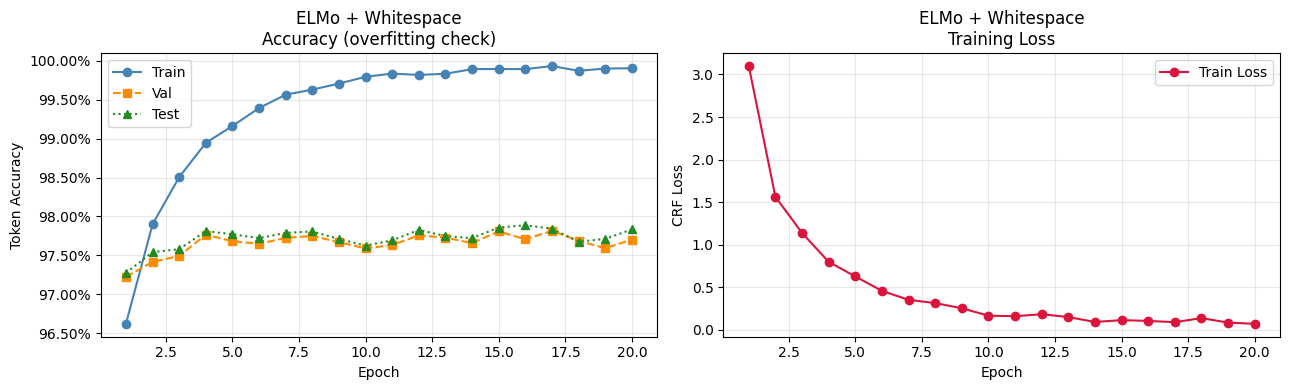

  Best Val F1  : 0.7868
  Best Test F1 : 0.7836

 Experiment: ELMo + NLTK
  Building datasets 
  Done. Training...
  Epoch 01 | loss 3.1003 | tr_acc 0.9656 | val_acc 0.9707 | te_acc 0.9719 | val_F1 0.6517
  Epoch 05 | loss 0.6235 | tr_acc 0.9920 | val_acc 0.9769 | te_acc 0.9769 | val_F1 0.7725
  Epoch 10 | loss 0.1941 | tr_acc 0.9976 | val_acc 0.9780 | te_acc 0.9784 | val_F1 0.7878
  Epoch 15 | loss 0.0915 | tr_acc 0.9988 | val_acc 0.9774 | te_acc 0.9783 | val_F1 0.7842
  Epoch 20 | loss 0.0444 | tr_acc 0.9996 | val_acc 0.9779 | te_acc 0.9781 | val_F1 0.7847


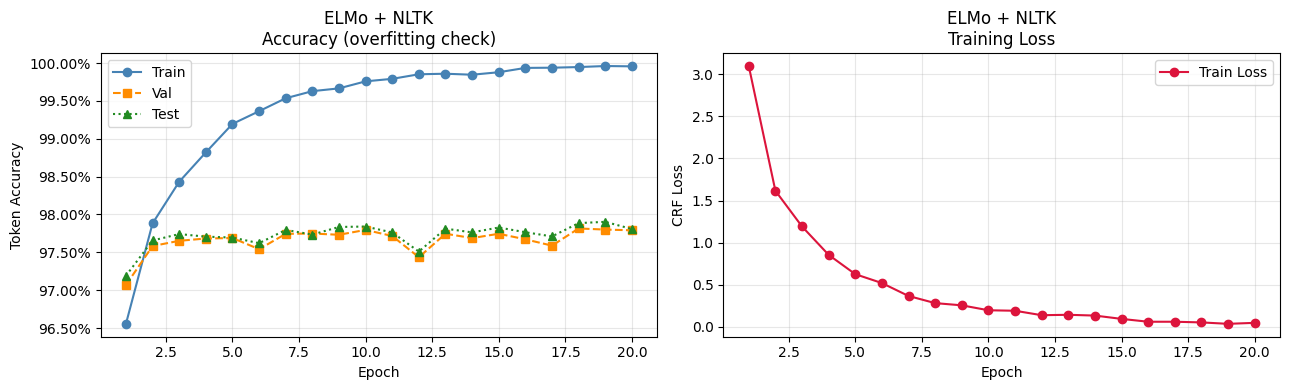

  Best Val F1  : 0.7896
  Best Test F1 : 0.7878

 Experiment: ELMo + BPE_WP
  Building datasets 
  Done. Training...
  Epoch 01 | loss 4.8129 | tr_acc 0.9643 | val_acc 0.9683 | te_acc 0.9682 | val_F1 0.6275
  Epoch 05 | loss 0.8578 | tr_acc 0.9925 | val_acc 0.9802 | te_acc 0.9806 | val_F1 0.7644
  Epoch 10 | loss 0.2222 | tr_acc 0.9983 | val_acc 0.9807 | te_acc 0.9815 | val_F1 0.7750
  Epoch 15 | loss 0.1406 | tr_acc 0.9991 | val_acc 0.9804 | te_acc 0.9809 | val_F1 0.7904
  Epoch 20 | loss 0.0401 | tr_acc 0.9997 | val_acc 0.9818 | te_acc 0.9822 | val_F1 0.7929


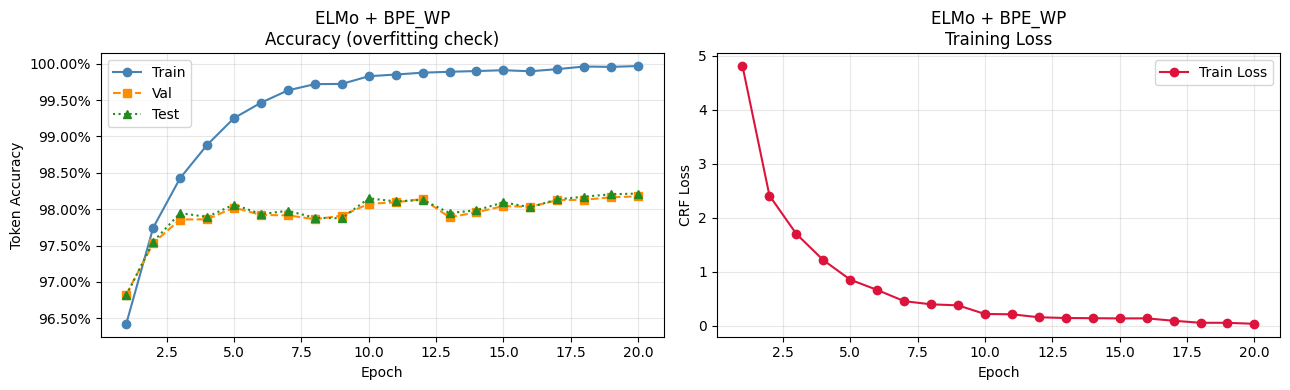

  Best Val F1  : 0.7972
  Best Test F1 : 0.7921
All ELMo experiments done!


In [25]:
# Remove any old ELMo entries
#results_table = [r for r in results_table if r['Embedding'] != 'ELMo']
#print(f'Ready. {len(results_table)} existing results kept.')

ELMO_EPOCHS = 20
ELMO_HIDDEN = 512

ELMO_TOK_MODES = {
    'Whitespace' : whitespace_tokenize,
    'NLTK'       : nltk_tokenize,
    'BPE_WP'     : hf_tokenize,
}

for tok_name, tok_fn in ELMO_TOK_MODES.items():
    label = f'ELMo + {tok_name}'
    print(f'\n{"="*60}')
    print(f' Experiment: {label}')
    print(f'{"="*60}')
    print('  Building datasets ')
    tr_ds = ELMoNERDataset(train_data, tag2idx, elmo_tf, tok_fn)
    vl_ds = ELMoNERDataset(val_data,   tag2idx, elmo_tf, tok_fn)
    te_ds = ELMoNERDataset(test_data,  tag2idx, elmo_tf, tok_fn)
    print('  Done. Training...')
    tr_loader = DataLoader(tr_ds, batch_size=32, shuffle=True,  collate_fn=elmo_collate_fn)
    vl_loader = DataLoader(vl_ds, batch_size=32, shuffle=False, collate_fn=elmo_collate_fn)
    te_loader = DataLoader(te_ds, batch_size=32, shuffle=False, collate_fn=elmo_collate_fn)
    model = ELMo_BiLSTM_CRF(
        elmo_dim=ELMO_DIM, hidden_dim=ELMO_HIDDEN,
        num_tags=NUM_CLASSES, dropout=0.3
    ).to(DEVICE)
    history = train_elmo_model(model, tr_loader, vl_loader, te_loader,
                                n_epochs=ELMO_EPOCHS, lr=1e-3, device=DEVICE)
    plot_accuracy_curves(history, title=label)
    results_table.append({
        'Embedding' : 'ELMo',
        'Tokenizer' : tok_name,
        'Val F1'    : round(history['val_f1'],  4),
        'Test F1'   : round(history['test_f1'], 4),
        'Val Acc'   : round(max(history['val_acc']),  4),
        'Test Acc'  : round(max(history['test_acc']), 4),
    })
    del model, tr_ds, vl_ds, te_ds
    if torch.cuda.is_available():
            torch.cuda.empty_cache()
    elif torch.backends.mps.is_available():
            # torch.mps.empty_cache may not exist on all PyTorch versions; guard it.
        try:
            torch.mps.empty_cache()
        except Exception:
            pass

print('All ELMo experiments done!')

## (13) Summary Report Table



In [26]:
import pandas as pd

df = pd.DataFrame(results_table)
df = df.sort_values('Test F1', ascending=False).reset_index(drop=True)

print('\n' + '='*70)
print('FULL RESULTS SUMMARY')
print('='*70)
print(df.to_string(index=False))
print('\nBest pipeline:', df.iloc[0]['Embedding'], '+', df.iloc[0]['Tokenizer'],
      '| Test F1:', df.iloc[0]['Test F1'])


FULL RESULTS SUMMARY
Embedding  Tokenizer  Val F1  Test F1  Val Acc  Test Acc
     ELMo     BPE_WP  0.7972   0.7921   0.9818    0.9822
     ELMo       NLTK  0.7896   0.7878   0.9781    0.9790
     BERT     BPE_WP  0.8072   0.7865   0.9804    0.9799
     BERT       NLTK  0.8050   0.7860   0.9806    0.9804
     ELMo Whitespace  0.7868   0.7836   0.9782    0.9789
     BERT Whitespace  0.7969   0.7805   0.9800    0.9789
    GloVe     BPE_WP  0.7830   0.7708   0.9812    0.9813
    GloVe       NLTK  0.7534   0.7349   0.9753    0.9753
    GloVe Whitespace  0.7521   0.7317   0.9762    0.9759
 FastText     BPE_WP  0.7296   0.7160   0.9769    0.9765
 Word2Vec     BPE_WP  0.7179   0.7051   0.9764    0.9762
 Word2Vec       NLTK  0.7144   0.6992   0.9734    0.9729
 Word2Vec Whitespace  0.7083   0.6969   0.9729    0.9728
 FastText Whitespace  0.7110   0.6904   0.9717    0.9702
 FastText       NLTK  0.7047   0.6873   0.9697    0.9697

Best pipeline: ELMo + BPE_WP | Test F1: 0.7921


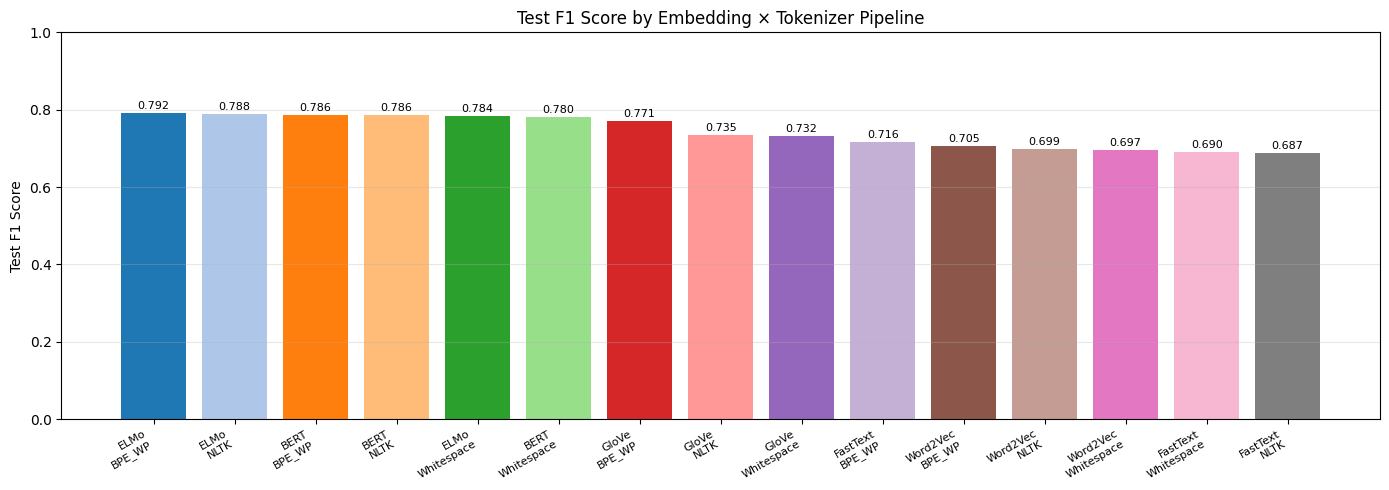

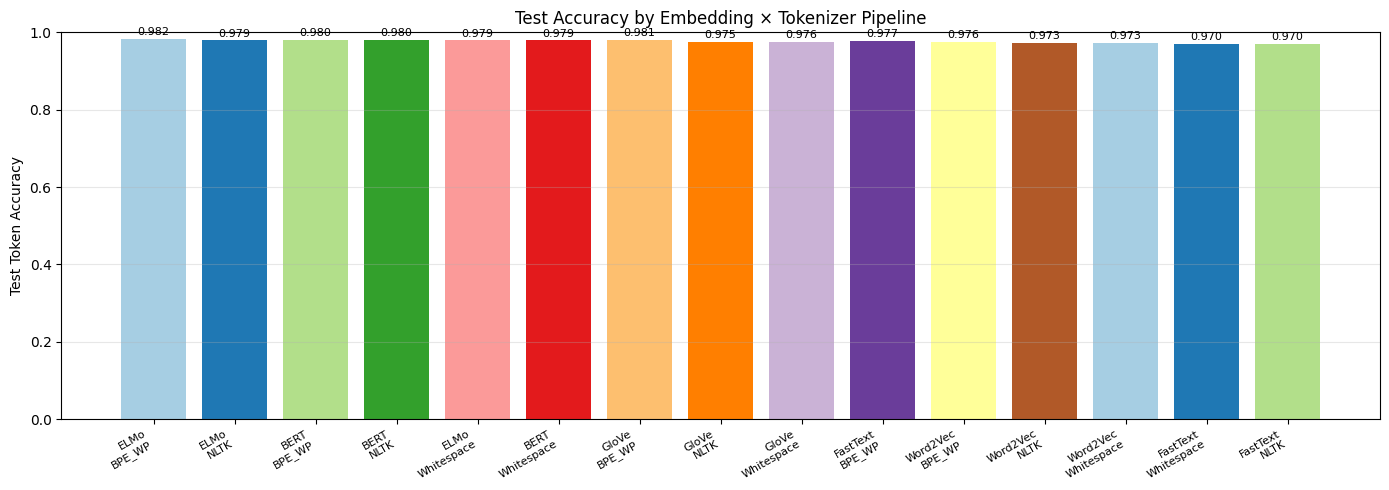

In [27]:
# ─── Bar chart: Test F1 per pipeline ─────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 5))
labels  = df['Embedding'] + '\n' + df['Tokenizer']
bars    = ax.bar(labels, df['Test F1'], color=plt.cm.tab20.colors[:len(df)])
ax.set_ylabel('Test F1 Score')
ax.set_title('Test F1 Score by Embedding × Tokenizer Pipeline')
ax.set_ylim(0, 1.0)
ax.grid(axis='y', alpha=0.3)
for bar, val in zip(bars, df['Test F1']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{val:.3f}', ha='center', va='bottom', fontsize=8)
plt.xticks(rotation=30, ha='right', fontsize=8)
plt.tight_layout()
plt.show()

# ─── Bar chart: Test Accuracy per pipeline ────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 5))
bars    = ax.bar(labels, df['Test Acc'], color=plt.cm.Paired.colors[:len(df)])
ax.set_ylabel('Test Token Accuracy')
ax.set_title('Test Accuracy by Embedding × Tokenizer Pipeline')
ax.set_ylim(0, 1.0)
ax.grid(axis='y', alpha=0.3)
for bar, val in zip(bars, df['Test Acc']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{val:.3f}', ha='center', va='bottom', fontsize=8)
plt.xticks(rotation=30, ha='right', fontsize=8)
plt.tight_layout()
plt.show()

## (14) Save results to CSV

In [ ]:
df.to_csv('s20861_ner_pipeline_results.csv', index=False)
print('Results saved to ner_pipeline_results.csv')

Results saved to ner_pipeline_results.csv
